In [4]:
from utils.models.auto_anomaly.dino_onnx import SlidingWindowAnomalyDetectorONNX

model = SlidingWindowAnomalyDetectorONNX(
    onnx_model_path="/workspace/src/utils/utils/models/auto_anomaly/assets/vit_large_dinov3_features.onnx",
    area_threshold=5,
    global_area_threshold=10)

model.fit(
    images_path="/mnt/nas/SPA006/241002-acquisitions/02-acquisitions_cropped/all/good",
    save_path="/workspace/src/SPA006/state.npz")

/workspace/venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Warmup completato con 4 immagini.
Stato salvato in: /workspace/src/SPA006/state.npz


Image 4 | dist=64.095 | thresh cls 61.766764548959245 |anomaly=True | warmup_done=True


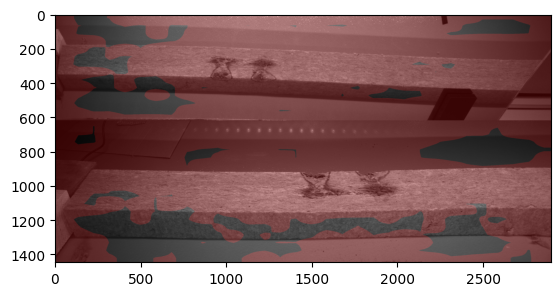

In [8]:
from utils.image_tools import random_image as ra
from matplotlib import pyplot as plt

img, filename = ra.load_random_image("/mnt/nas/SPA006/241002-acquisitions/02-acquisitions_cropped/all/bad")

overlay, mask, discard = model.run(img)

plt.imshow(overlay)

In [1]:
from utils.models.auto_anomaly.auto_anomaly import AutoAnomaly

model = AutoAnomaly(warmup_window_size=2)

model.fit(
    images_path="/mnt/nas/VTR002/IMG_4_ANOMALY/good",
    save_path="/workspace/src/SPA006/state.npz", 
    make_sample=True,
    n=10)

/workspace/venv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Sampling attivo: selezione casuale di 10 immagini su 283.


100%|██████████| 10/10 [00:34<00:00,  3.46s/it]


Warmup completato con 10 immagini.
Stato salvato in: /workspace/src/SPA006/state.npz


Image 1 | dist=93.293 | thresh cls 31.717194799828512 | anomaly=True | warmup_done=True


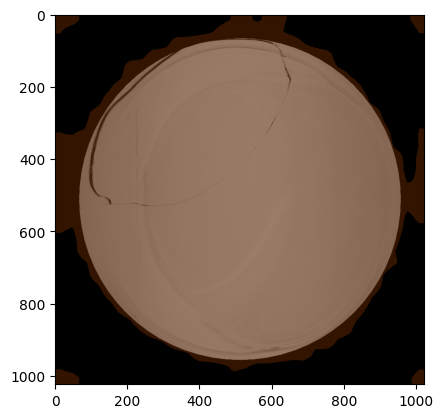

In [3]:
from utils.models.auto_anomaly.auto_anomaly import AutoAnomaly
from utils.image_tools import random_image as ra
from matplotlib import pyplot as plt

model = AutoAnomaly(warmup_window_size=2, area_threshold=5, global_area_threshold=10)
img, filename = ra.load_random_image("/mnt/nas/VTR002/IMG_4_ANOMALY/defective")
overlay, mask, discard = model.predict(img)

plt.imshow(overlay)